<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-gymnasium-temporal-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Gymnasium with Convolutional Autoencoders with a Bottleneck

## Setup

Install non-optional packages:

In [217]:
!pip install wandb datasets tsilva_notebook_utils==0.0.24

🔑 Loading API keys and authentication tokens from Colab secrets:

In [218]:
from tsilva_notebook_utils.colab import load_secrets_into_env

load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL',
    'NOTIFICATION_AUTH_TOKEN'
])

Define configuration:

In [219]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random seed for reproducibility
    seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID
    dataset_id = "tsilva/GymnasiumRecording__SuperMarioBros_Nes"  # @param {type: "string"}

    # @markdown
    frame_stack_size = 1  # @param {type: "number"}

    # @markdown How many frames to skip
    frame_skip = 4 # @param {type: "number"}

    image_scale = 0.5  # @param {type: "number"}

    sparsity_loss_alpha = 0.01  # @param {type: "number"}

    # @markdown Convert frames to grayscale before training
    convert_to_grayscale = True  # @param {type: "boolean"}

    # @markdown Noise factor for input corruption
    noise_factor = 0  # @param {type: "number"}

    # @markdown ### 🧠 Model Settings

    # @markdown Latent space dimensionality
    latent_dim = 512  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Number of training epochs
    n_epochs = 1000  # @param {type: "integer"}

    # @markdown Batch size
    batch_size = 512  # @param {type: "integer"}

    # @markdown Gradient clipping norm (0 = disabled)
    max_grad_norm = 0  # @param {type: "number"}

    # @markdown Weight decay for regularization
    weight_decay = 0  # @param {type: "number"}

    # @markdown Warmup ratio for learning rate scheduler
    warmup_ratio = 0  # @param {type: "number"}

    # @markdown Loss function to use
    loss_function = "mse"  # @param ["mse", "ssim"]

    # @markdown Learning rate for the optimizer
    learning_rate = 0.001  # @param {type: "number"}

    os.environ["NOTEBOOK_ID"] = notebook_id_from_title()

    return dict(
        # Notebook settings
        seed=seed,

        sparsity_loss_alpha=sparsity_loss_alpha,
        # Dataset
        dataset_id=dataset_id,
        frame_skip=frame_skip,
        frame_stack_size=frame_stack_size,
        image_scale=image_scale,
        convert_to_grayscale=convert_to_grayscale,
        noise_factor=noise_factor,

        # Model
        latent_dim=latent_dim,

        # Training
        n_epochs=n_epochs,
        batch_size=batch_size,
        max_grad_norm=max_grad_norm,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        loss_function=loss_function,
        learning_rate=learning_rate
    )

CONFIG = setup_config()

In [220]:
import torch
torch.backends.cudnn.benchmark = True

In [221]:
from wandb import login
WANDB_API_KEY = os.getenv("WANDB_API_KEY"); assert WANDB_API_KEY is not None, "WANDB_API_KEY environment variable is not set"
login(key=WANDB_API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

Load dataset:

In [222]:
from datasets import load_dataset
dataset = load_dataset(CONFIG["dataset_id"], split="train")

Show sample dataset image:

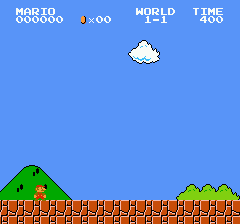

In [223]:
sample_image = dataset["image"][0]
sample_image

Convert image to grayscale:

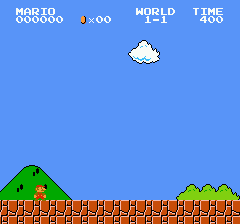

In [224]:
grayscale_image = sample_image.convert("L")
if CONFIG["convert_to_grayscale"]: sample_image = grayscale_image
sample_image

Downscale image:

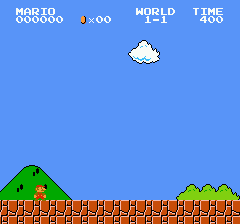

In [225]:
grayscale_image = sample_image.convert("L")
if CONFIG["convert_to_grayscale"]: sample_image = grayscale_image
sample_image

Scale image:

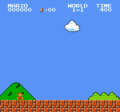

In [226]:
from torchvision.transforms.functional import to_tensor, resize, to_pil_image
sample_image_t = to_tensor(sample_image)
image_height, image_width = sample_image_t.shape[1], sample_image_t.shape[2]
image_scale = CONFIG["image_scale"]
resized_tensor = resize(sample_image_t, [int(image_height * image_scale), int(image_width * image_scale)])
sample_image = to_pil_image(resized_tensor)
sample_image

Normalize image tensor:

In [227]:
from torchvision.transforms.functional import to_tensor
sample_image_t = to_tensor(sample_image)

Retrieve dataset image dimensions:

In [228]:
n_channels, image_height, image_width = sample_image_t.shape
n_channels, image_height, image_width

(3, 112, 120)

Create the model:

In [229]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, latent_dim=None, use_fc=True):
        super(ConvAutoencoder, self).__init__()

        if latent_dim is None: latent_dim = CONFIG['latent_dim']
        self.use_fc = use_fc

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Dummy forward pass to compute shape
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.numel()
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_fc:
            self.fc_enc = nn.Linear(self._flattened_size, latent_dim)
            self.fc_dec = nn.Linear(latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, 2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_fc:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_fc:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        else:
            z = z  # z already in conv shape
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)

        self._encoded = z

        out = self.decode(z)
        return out

use_fc = CONFIG['latent_dim'] > 0
model = ConvAutoencoder(CONFIG["frame_stack_size"] * n_channels, n_channels, image_height, image_width, use_fc=use_fc)
model

ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=26880, out_features=512, bias=True)
  (fc_dec): Linear(in_features=512, out_features=26880, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

Let's check how much compression the encoder is providing, first let's check how many parameters are currently required to encode a sample image:

In [230]:
sample_image_t.shape, sample_image_t.numel()

(torch.Size([3, 112, 120]), 40320)

Now let's check how many are required to represent a reconstructed picture:

In [231]:
#stack_t = torch.cat([sample_image_t.squeeze()] * CONFIG['frame_stack_size'])
#encoded_t = model.encode(stack_t)
#encoded_t.shape, encoded_t.numel()

Assert that the encoded dimensions match the configured latent dimension:

In [232]:
#latent_dim = encoded_t.numel()
#assert latent_dim == CONFIG['latent_dim']

And now we can calculate how much compression we're getting:

In [233]:
#compression = latent_dim / sample_image_t.numel()
#print(f"Compression: {compression * 100:.2f}% of original size")

Check what image with noise looks like:

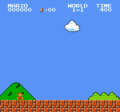

In [234]:
noisy_sample_image_t = sample_image_t + torch.randn_like(sample_image_t) * CONFIG['noise_factor']
to_pil = transforms.ToPILImage()
noisy_sample_image = to_pil(noisy_sample_image_t)
noisy_sample_image

Let's process dataset to ensure it has configured transformations (eg: grayscaling and image noise):

In [235]:
import torch
import multiprocessing
from torchvision.transforms.functional import to_tensor, to_pil_image
from PIL import Image

def pad_to_multiple(img, multiple=8):
    width, height = img.size
    new_width = (width + multiple - 1) // multiple * multiple
    new_height = (height + multiple - 1) // multiple * multiple
    padded = Image.new("L" if img.mode == "L" else "RGB", (new_width, new_height))
    padded.paste(img, (0, 0))
    return padded

# TODO: optimize by not performing transforms when they dont' exist
def _map_batch(batch):
    if CONFIG['convert_to_grayscale']:
        images = [img.convert("L") for img in batch["image"]]
    else:
        images = batch["image"]

    image_ts = [to_tensor(img) for img in images]

    noise = torch.randn_like(torch.stack(image_ts)) * CONFIG["noise_factor"]
    noisy_ts = torch.clamp(torch.stack(image_ts) + noise, 0.0, 1.0)

    inputs = [to_pil_image(noisy) for noisy in noisy_ts]
    targets = [to_pil_image(orig) for orig in image_ts]

    # Resize both inputs and targets
    scale = CONFIG["image_scale"]
    if scale < 1.0:
        inputs = [img.resize((int(img.width * scale), int(img.height * scale)), Image.BILINEAR) for img in inputs]
        targets = [img.resize((int(img.width * scale), int(img.height * scale)), Image.BILINEAR) for img in targets]

    #inputs = [pad_to_multiple(img, multiple=8) for img in inputs]
    #targets = [pad_to_multiple(img, multiple=8) for img in targets]

    return dict(
        input=inputs,
        target=targets
    )

dataset = dataset.map(
    _map_batch,
    batched=True,
    batch_size=64
)

Render video with procssed images to double check that noise level is appropriate:

In [236]:
import tempfile
from tsilva_notebook_utils.video import save_frames_to_dir, render_loader_video

def collate_fn(batch):
    return (torch.stack([to_tensor(x["input"]) for x in batch]), torch.stack([to_tensor(x["target"]) for x in batch]))

loader = DataLoader(
    dataset.select(range(500)),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn
)
#render_loader_video(loader)

Create frame collator that takes frame stacking into account:

In [237]:
from torch.utils.data import TensorDataset, DataLoader
X = torch.stack([to_tensor(x) for x in dataset["input"]])
Y = torch.stack([to_tensor(x) for x in dataset["target"]])

# Every 4th item goes to the train set (start from index 0, step 4)
frame_skip = CONFIG['frame_skip']
train_X = X[::frame_skip]
train_Y = Y[::frame_skip]

# All others go to the test set (use a mask)
indices = torch.arange(len(X))
mask = torch.ones(len(X), dtype=bool)
mask[::frame_skip] = False  # Mask out every 4th item
val_X = X[mask]
val_Y = Y[mask]

# Wrap in TensorDataset
train_dataset = TensorDataset(train_X, train_Y)
val_dataset = TensorDataset(val_X, val_Y)
test_dataset = TensorDataset(X, Y)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    pin_memory=True,
    num_workers=multiprocessing.cpu_count(),
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    pin_memory=True,
    shuffle=False,
    num_workers=multiprocessing.cpu_count()
)

In [238]:
render_loader_video(test_loader)

Rendering frames: 100%|██████████| 6/6 [00:05<00:00,  1.17it/s]


Create model, loss function and optimizer:

In [239]:
from tsilva_notebook_utils.torch import get_current_device

device = get_current_device()
use_fc = CONFIG['latent_dim'] > 0
model = ConvAutoencoder(CONFIG['frame_stack_size'] * n_channels, n_channels, image_height, image_width, use_fc=use_fc).to(device)
model = torch.compile(model)

if CONFIG['loss_function'] == 'mse':
    loss_fn = nn.MSELoss()
elif CONFIG['loss_function'] == 'ssim':
    from pytorch_msssim import MS_SSIM
    ms_ssim = MS_SSIM(data_range=1.0, size_average=True, channel=n_channels)
    loss_fn = lambda pred, target: 1 - ms_ssim(pred, target)

optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])

Test a forward pass through the model to make sure shapes are accurate:

In [240]:
model.eval()
for x, y in train_loader:
    x = x.to(device)
    y = y.to(device)
    print(x.shape)
    print(y.shape)
    assert torch.equal(x, y), "Input and target tensors are not the same"
    with torch.no_grad(): y_pred = model(x)
    print(y_pred.shape)
    loss = loss_fn(y_pred, y)
    print(loss.item())
    break

torch.Size([512, 3, 112, 120])
torch.Size([512, 3, 112, 120])
torch.Size([512, 3, 112, 120])
0.1019444540143013


Run training:

In [241]:
import wandb
from tqdm import tqdm
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tsilva_notebook_utils.torch import calc_model_grad_norms

# Iterate over batches
from torch import autocast, GradScaler

# TODO: is calculating grad norms slow?
def train(
    model,
    loss_fn,
    optimizer,
    train_loader,
    n_epochs=None,
    eval_fn=None,
    learning_rate=None,
    max_grad_norm=None,
    warmup_ratio=None
):
    NOTEBOOK_ID = os.getenv("NOTEBOOK_ID"); assert NOTEBOOK_ID is not None, "NOTEBOOK_ID environment variable is not set"
    with wandb.init(project=NOTEBOOK_ID, config=CONFIG) as run:
        if n_epochs is None: n_epochs = CONFIG['n_epochs']
        if learning_rate is None: learning_rate = CONFIG['learning_rate']
        if max_grad_norm is None: max_grad_norm = CONFIG['max_grad_norm']
        if warmup_ratio is None: warmup_ratio = CONFIG['warmup_ratio']

        scaler = GradScaler('cuda')

        # Set model to training mode
        #model.train()

        # Watch model for gradient logging with wandb
        wandb.watch(model, log="all")

        # Linear warmup schedule: linearly increase LR for warmup_steps, then keep constant
        total_steps = n_epochs * len(train_loader)
        warmup_steps = int(warmup_ratio * total_steps) if warmup_ratio else 0
        def lr_lambda(current_step): return float(current_step) / float(max(1, warmup_steps)) if current_step < warmup_steps else 1.0
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

        # Progress bar for training
        global_step = 0
        device = next(model.parameters()).device
        with tqdm(range(n_epochs), desc="Training") as pbar:
            for epoch in pbar:
                losses, accuracies, grad_norms, latent_sparsities, layer_norms = [], [], [], [], {}
                last_layer_norms = {}

                model.train()
                for x_batch, y_batch in train_loader:
                    x_batch = x_batch.to(device)
                    y_batch = y_batch.to(device)

                    global_step += 1

                    optimizer.zero_grad()

                    with autocast('cuda'):
                        # Forward pass
                        logits = model(x_batch)

                        # Calculate loss
                        reconstruction_loss = loss_fn(logits, y_batch)
                        if CONFIG['sparsity_loss_alpha'] > 0.0:
                            sparsity_loss = CONFIG['sparsity_loss_alpha'] * torch.mean(torch.abs(model._encoded))
                            loss = reconstruction_loss + sparsity_loss
                        else:
                            loss = reconstruction_loss

                        losses.append(loss.item())

                    scaler.scale(loss).backward()
                    if max_grad_norm:
                        scaler.unscale_(optimizer)
                        clip_grad_norm_(model.parameters(), max_grad_norm)
                    scaler.step(optimizer)
                    scaler.update()

                    # Perform learning rate scheduler step
                    scheduler.step()

                    # Perform backpropagation
                    #loss.backward()

                    # Optionally clip gradients to avoid exploding gradients
                    #if max_grad_norm: clip_grad_norm_(model.parameters(), max_grad_norm)

                    # Calculate gradient norms for monitoring
                    #_grad_norm, _layer_norms = calc_model_grad_norms(model)
                    #grad_norms.append(_grad_norm)

                    #last_layer_norms = layer_norms

                    # Perform optimization step
                    #optimizer.step()

                    # Calculate latent sparsity with threshold
                    with torch.no_grad():
                        threshold = 1e-3  # You can adjust this value as needed
                        encoded = model._encoded
                        num_elements = encoded.numel()
                        num_zeros = torch.sum(torch.abs(encoded) < threshold).item()
                        latent_sparsity = num_zeros / num_elements
                        #print(latent_sparsity)
                        latent_sparsities.append(latent_sparsity)

                    #print(f"Sparsity: {sparsity:.4f} ({sparsity * 100:.2f}%)")

                    # Calculate training accuracy
                    #with torch.no_grad():
                    #    predicted = torch.argmax(logits, dim=1)
                    #    accuracy = (predicted == y_batch).float().mean().item()
                    #    accuracies.append(accuracy)

                if epoch % 3 == 0:
                    model.eval()
                    val_losses = []
                    for x_batch, y_batch in val_loader:
                        x_batch = x_batch.to(device)
                        y_batch = y_batch.to(device)
                        with torch.no_grad():
                            logits = model(x_batch)
                            reconstruction_loss = loss_fn(logits, y_batch)
                            val_losses.append(reconstruction_loss.item())
                    val_loss = sum(val_losses) / len(val_losses)

                # Log W&B stats
                train_loss = sum(losses) / len(losses)
                latent_sparsity = sum(latent_sparsities) / len(latent_sparsities)
                #train_accuracy = sum(accuracies) / len(accuracies)
                #train_grad_norm = sum(grad_norms) / len(grad_norms)
                current_lr = scheduler.get_last_lr()[0]
                wandb_stats = {
                    'meta/epoch': epoch + 1,
                    'meta/step': global_step,
                    'meta/learning_rate': current_lr,

                    'train/loss': train_loss,
                    'train/reconstruction_loss': reconstruction_loss.item(),
                    'train/sparsity_loss': sparsity_loss.item(),
                    'train/latent_sparsity' : latent_sparsity,
                    'val/loss' : val_loss,
                    #'train/accuracy': train_accuracy,

                    #'grad/total_norm': train_grad_norm,
                }
                #for _layer_name, _layer_norm in _layer_norms.items(): wandb_stats[f'grad/layer/{_layer_name}'] = _layer_norm

                pbar_stats = {
                    'epoch': epoch + 1,
                    'train_loss': f'{train_loss:.4f}',
                    'lr': f'{current_lr:.6e}',
                    #'grad_norm': f'{train_grad_norm:.2f}',
                    #'train_acc': f'{train_accuracy * 100:.2f}%'
                }

                # Run evaluation on validation set
                if eval_fn:
                    result = eval_fn()
                    val_loss = result['loss']
                    val_accuracy = result['accuracy']
                    wandb_stats['val/loss'] = val_loss
                    wandb_stats['val/accuracy'] = val_accuracy
                    pbar_stats['val_acc'] =  f'{val_accuracy * 100:.2f}%'

                # Log stats to w-andb
                wandb.log(wandb_stats, step=global_step)

                # Show key metrics in progress bar
                pbar.set_postfix(pbar_stats)

                # Early stopping if training accuracy hits 100%
                #if train_accuracy == 1.0:
                #    print("\nTraining finished early: model perfectly fit the training set.")
                #    break

        return run

train(model, loss_fn, optimizer, train_loader)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Training:   7%|▋         | 68/1000 [01:27<20:02,  1.29s/it, epoch=68, train_loss=0.0159, lr=1.000000e-03]
Traceback (most recent call last):
  File "<ipython-input-241-2923bde6d97d>", line 72, in train
    losses.append(loss.item())
    ^^^^^^^^^^^
KeyboardInterrupt


meta/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
meta/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
meta/step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
train/latent_sparsity,▁▁▂█▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,███████▇▇▇▇▆▆▆▆▅▅▅▅▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/reconstruction_loss,██▇█████▇▇▆▆▆▆▅▅▅▅▅▄▃▃▃▂▃▂▂▁▂▂▂▂▁▂▂▁▂▁▁▁
train/sparsity_loss,▅▁▁▁▁▁▇▄▃▄▃▄▃▃▃▅▆▆█▇▅▅▅▄▅▄▄▄▄▄▄▄▄▄▄▄▃▄▃▄
val/loss,███████▇▇▇▇▆▆▆▅▅▅▅▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
meta/epoch,68
meta/learning_rate,0.001
meta/step,136


KeyboardInterrupt: 

In [242]:
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir

latent_dim = CONFIG['latent_dim']
with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for i in range(latent_dim):
        encoded = torch.zeros(latent_dim, device=device)
        encoded[i] = 1.0
        encoded = encoded.unsqueeze(0)  # shape: (1, latent_dim)
        decoded = model.decode(encoded)
        frames.append(decoded.squeeze())
    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10)
video

Saving frames: 100%|██████████| 512/512 [00:00<00:00, 1343.60it/s]


In [243]:
from tsilva_notebook_utils.video import save_frames_to_dir, render_video_from_dir
import torch.nn.functional as F
import random

latent_dim = CONFIG['latent_dim']
sparsity_ratio = 0.5  # Match your model's average sparsity
num_frames = latent_dim  # or choose more/less depending on what you want to visualize

with tempfile.TemporaryDirectory() as temp_dir:
    frames = []
    for _ in range(num_frames):
        # Start with all zeros
        encoded = torch.zeros(latent_dim, device=device)

        # Randomly activate a sparse subset
        n_active = int(latent_dim * sparsity_ratio)
        active_indices = random.sample(range(latent_dim), n_active)

        # Assign random values (or fixed if you want consistency)
        encoded[active_indices] = torch.rand(n_active, device=device)

        # Decode and save frame
        decoded = model.decode(encoded.unsqueeze(0))
        frame = decoded.squeeze().detach().cpu()
        frames.append(frame)

    save_frames_to_dir(frames, temp_dir)
    video = render_video_from_dir(temp_dir, fps=10)

video

Saving frames: 100%|██████████| 512/512 [00:00<00:00, 1480.64it/s]


Render video of autoencoder predictions:

In [ ]:
from tsilva_notebook_utils.video import render_autoencoder_video, render_video_from_dir
render_autoencoder_video(model, test_loader, compare_inputs=False)

⏰ Setting up auto-notification and resource management:

In [ ]:
from tsilva_notebook_utils.colab import notify_and_disconnect_after_timeout
notify_and_disconnect_after_timeout()